# 04 — Voiceprint Verification Model

Trains a voice-identity classifier on the MFCC / spectral features produced by
`process_audio.py` (`data/audio_features.csv`).

**Decisions**
- Features: `MFCC_1`..`MFCC_13`, `SpectralRolloff`, `SpectralCentroid`, `RMSEnergy`,
  `ZeroCrossingRate`.
- Target: `Person` — an **identification** model ("whose voice is this?"), not open-set
  verification — same framing as notebook 03.
- **Group-aware split**: each `(Person, Phrase)` pair is one physical recording; its 4
  augmented variants (original/pitch-shift/time-stretch/noise) are near-duplicates. Splits
  group all variants of a recording onto the same side via `StratifiedGroupKFold`. Only 2
  recordings per person exist, so `N_SPLITS=2` (each fold holds out exactly 1 recording's
  4 rows per person).
- **Model**: `StandardScaler` + `LogisticRegression`, same architecture as the facial
  recognition model, for consistency across modalities.
- **Threshold-based unknown handling**: same `UNKNOWN_THRESHOLD` mechanism as notebook 03 —
  max class probability below threshold => `UNKNOWN`.
- **Distance-based novelty guard**: discovered necessary while testing the Task 6 CLI demo —
  synthetic white-noise audio was classified as `person1` with 0.99 confidence, because a
  linear classifier extrapolates confidently far outside its training distribution instead
  of expressing uncertainty. A sample is now only accepted if it is *also* within
  `DISTANCE_MARGIN` × the largest observed intra-class distance from its predicted class's
  centroid (in scaled feature space); otherwise it is rejected as `UNKNOWN` regardless of
  confidence.
- **Small-N caveat**: only 2 source recordings per person (4 groups total) — metrics are
  directional, not production-grade.


In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

DATA_PATH = Path("../data/audio_features.csv")
MODEL_PATH = Path("../models/voice_verification_model.pkl")
ENCODER_PATH = Path("../models/voice_label_encoder.pkl")
CONFIG_PATH = Path("../models/voice_verification_config.json")
REPORT_DIR = Path("../reports")
REPORT_PATH = REPORT_DIR / "voice_verification_report.md"
CM_PATH = REPORT_DIR / "voice_verification_confusion_matrix.png"
NON_FEATURE_COLS = {"Person", "Audio", "Phrase", "SourcePath"}
RANDOM_STATE = 42
N_SPLITS = 2
UNKNOWN_THRESHOLD = 0.6
DISTANCE_MARGIN = 1.5  # multiplier on max observed intra-class distance (novelty guard)


## 1. Load & validate


In [2]:
df = pd.read_csv(DATA_PATH, encoding="utf-8", sep=",")
print(f"[OK] Loaded {DATA_PATH.name}  shape={df.shape}")

required = ["Person", "Phrase"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"{DATA_PATH.name} missing columns: {missing}")

feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]
if not feature_cols:
    raise ValueError(f"No feature columns found in {DATA_PATH.name}")

assert df[feature_cols].isnull().sum().sum() == 0, "Audio features contain nulls"
assert df["Person"].nunique() >= 2, "Need at least 2 known people to train a classifier"

print("People:", df["Person"].value_counts().to_dict())
print("Feature columns:", len(feature_cols))
print(df[["Person", "Audio", "Phrase"]].head(20))


[OK] Loaded audio_features.csv  shape=(16, 21)
People: {'person1': 8, 'person2': 8}
Feature columns: 17
     Person                            Audio               Phrase
0   person1                  yes_approve.wav          yes_approve
1   person1            yes_approve_pitch.wav          yes_approve
2   person1          yes_approve_stretch.wav          yes_approve
3   person1            yes_approve_noise.wav          yes_approve
4   person1          confirm_transaction.wav  confirm_transaction
5   person1    confirm_transaction_pitch.wav  confirm_transaction
6   person1  confirm_transaction_stretch.wav  confirm_transaction
7   person1    confirm_transaction_noise.wav  confirm_transaction
8   person2                  yes_approve.wav          yes_approve
9   person2            yes_approve_pitch.wav          yes_approve
10  person2          yes_approve_stretch.wav          yes_approve
11  person2            yes_approve_noise.wav          yes_approve
12  person2          confirm_transacti

## 2. Group-aware labels

Each `(Person, Phrase)` pair is one physical recording; its augmented variants must stay
together on one side of any split.


In [3]:
df["group"] = df["Person"].astype(str) + "_" + df["Phrase"].astype(str)

label = LabelEncoder()
y = label.fit_transform(df["Person"])
X = df[feature_cols].to_numpy()
groups = df["group"].to_numpy()

print("Classes:", list(label.classes_))
print("Unique (Person, Phrase) recordings:", df["group"].nunique())


Classes: ['person1', 'person2']
Unique (Person, Phrase) recordings: 4


## 3. Model pipeline


In [4]:
def build_pipeline() -> Pipeline:
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "classifier",
                LogisticRegression(
                    max_iter=2000,
                    random_state=RANDOM_STATE,
                    class_weight="balanced",
                ),
            ),
        ]
    )


## 4. Grouped, stratified cross-validation

`StratifiedGroupKFold` keeps every recording's 4 variants together while balancing people
across folds. Each fold asserts no recording group appears on both sides of the split.


In [5]:
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

fold_accuracy, fold_f1 = [], []
holdout_idx = None  # keep fold 0's split for the detailed holdout report below

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
    assert set(groups[train_idx]).isdisjoint(groups[test_idx]), (
        f"Recording leakage across fold {fold} split"
    )

    pipe = build_pipeline()
    pipe.fit(X[train_idx], y[train_idx])
    preds = pipe.predict(X[test_idx])

    acc = accuracy_score(y[test_idx], preds)
    f1 = f1_score(y[test_idx], preds, average="macro", zero_division=0)
    fold_accuracy.append(acc)
    fold_f1.append(f1)
    print(
        f"Fold {fold}: accuracy={acc:.4f}  f1_macro={f1:.4f}  "
        f"train={len(train_idx)} test={len(test_idx)}"
    )

    if holdout_idx is None:
        holdout_idx = (train_idx, test_idx)

fold_accuracy = np.array(fold_accuracy)
fold_f1 = np.array(fold_f1)
print(f"\nMean accuracy: {fold_accuracy.mean():.4f}  std: {fold_accuracy.std():.4f}")
print(f"Mean F1 (macro): {fold_f1.mean():.4f}  std: {fold_f1.std():.4f}")


Fold 0: accuracy=1.0000  f1_macro=1.0000  train=8 test=8
Fold 1: accuracy=0.8750  f1_macro=0.8730  train=8 test=8

Mean accuracy: 0.9375  std: 0.0625
Mean F1 (macro): 0.9365  std: 0.0635


## 5. Holdout evaluation (fold 0) + threshold-based unknown handling


Accuracy:      1.0000
F1 (macro):    1.0000
F1 (weighted): 1.0000
Log loss:      0.0300

UNKNOWN_THRESHOLD=0.6 -> 0/8 holdout predictions rejected as UNKNOWN (all rows here are known people; expected low/zero)

              precision    recall  f1-score   support

     person1       1.00      1.00      1.00         4
     person2       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



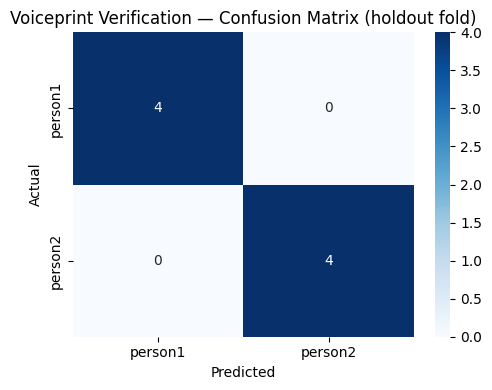

Saved confusion matrix -> /Users/macbookpro/Documents/Formative-2---Data-Preprocessing/multimodal-authentication/reports/voice_verification_confusion_matrix.png


In [6]:
train_idx, test_idx = holdout_idx
model = build_pipeline()
model.fit(X[train_idx], y[train_idx])

y_test = y[test_idx]
y_proba = model.predict_proba(X[test_idx])
y_pred = model.predict(X[test_idx])
labels_idx = list(range(len(label.classes_)))

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro", labels=labels_idx, zero_division=0)
f1_weighted = f1_score(y_test, y_pred, average="weighted", labels=labels_idx, zero_division=0)

log_loss_value = None
log_loss_note = ""
try:
    log_loss_value = float(log_loss(y_test, y_proba, labels=labels_idx))
    if np.isnan(log_loss_value) or np.isinf(log_loss_value):
        raise ValueError("Log loss is undefined (NaN/Inf).")
except ValueError as exc:
    log_loss_value = None
    log_loss_note = f"Log loss could not be computed: {exc}."

clf_report = classification_report(
    y_test, y_pred, labels=labels_idx, target_names=label.classes_, zero_division=0
)

# Threshold-based rejection: below UNKNOWN_THRESHOLD confidence => treat as UNKNOWN
max_proba = y_proba.max(axis=1)
predicted_labels = np.where(
    max_proba >= UNKNOWN_THRESHOLD, label.inverse_transform(y_pred), "UNKNOWN"
)
n_rejected = int((predicted_labels == "UNKNOWN").sum())

print(f"Accuracy:      {accuracy:.4f}")
print(f"F1 (macro):    {f1_macro:.4f}")
print(f"F1 (weighted): {f1_weighted:.4f}")
print(f"Log loss:      {log_loss_value:.4f}" if log_loss_value is not None else log_loss_note)
print(
    f"\nUNKNOWN_THRESHOLD={UNKNOWN_THRESHOLD} -> {n_rejected}/{len(test_idx)} holdout "
    "predictions rejected as UNKNOWN (all rows here are known people; expected low/zero)"
)
print()
print(clf_report)

cm = confusion_matrix(y_test, y_pred, labels=labels_idx)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label.classes_,
    yticklabels=label.classes_,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Voiceprint Verification — Confusion Matrix (holdout fold)")
plt.tight_layout()
REPORT_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(CM_PATH, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved confusion matrix -> {CM_PATH.resolve()}")


## 6. Fit final model on all data + persist

The holdout/CV folds above are for evaluation only; the deployed model is refit on every
available row so the CLI demo (Task 6) has access to all known people/recordings.


In [7]:
final_model = build_pipeline()
final_model.fit(X, y)

# Softmax/sigmoid confidence from a linear classifier is not a reliable unknown-
# input detector: LogisticRegression extrapolates *confidently* far outside the
# training distribution (verified empirically — random noise scored >0.99 "known
# person" confidence). A distance-to-centroid novelty check catches this: reject
# as UNKNOWN if the scaled sample is farther from its predicted class centroid
# than any training point was, times a safety margin.
scaler = final_model.named_steps["scaler"]
X_scaled = scaler.transform(X)
centroids: dict[str, list[float]] = {}
max_intra_class_distance: dict[str, float] = {}
for class_idx, class_name in enumerate(label.classes_):
    class_points = X_scaled[y == class_idx]
    centroid = class_points.mean(axis=0)
    centroids[class_name] = centroid.tolist()
    max_intra_class_distance[class_name] = float(
        np.linalg.norm(class_points - centroid, axis=1).max()
    )

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(final_model, MODEL_PATH)
joblib.dump(label, ENCODER_PATH)

config = {
    "unknown_threshold": UNKNOWN_THRESHOLD,
    "feature_columns": feature_cols,
    "classes": list(label.classes_),
    "centroids": centroids,
    "max_intra_class_distance": max_intra_class_distance,
    "distance_margin": DISTANCE_MARGIN,
}
CONFIG_PATH.write_text(json.dumps(config, indent=2), encoding="utf-8")

print(f"Saved model   -> {MODEL_PATH.resolve()}")
print(f"Saved encoder -> {ENCODER_PATH.resolve()}")
print(f"Saved config  -> {CONFIG_PATH.resolve()}")
print("Max intra-class distance (scaled space):", max_intra_class_distance)


Saved model   -> /Users/macbookpro/Documents/Formative-2---Data-Preprocessing/multimodal-authentication/models/voice_verification_model.pkl
Saved encoder -> /Users/macbookpro/Documents/Formative-2---Data-Preprocessing/multimodal-authentication/models/voice_label_encoder.pkl
Saved config  -> /Users/macbookpro/Documents/Formative-2---Data-Preprocessing/multimodal-authentication/models/voice_verification_config.json
Max intra-class distance (scaled space): {'person1': 4.938360272608367, 'person2': 4.216524250248516}


## 7. Export evaluation report


In [8]:
def _fmt(v):
    return f"{v:.4f}" if v is not None else "N/A"

log_loss_section = f"\n> {log_loss_note}\n" if log_loss_note else ""

report = f"""# Voiceprint Verification — Evaluation Report

Generated by `notebooks/04_voiceprint_verification.ipynb`.

## Dataset statistics

| Item | Value |
|------|-------|
| Source file | `{DATA_PATH.name}` |
| Rows (audio variants) | {len(df)} |
| Unique source recordings (groups) | {df['group'].nunique()} |
| Known people | {len(label.classes_)} ({', '.join(label.classes_)}) |
| Feature dimensions | {len(feature_cols)} |
| CV folds | {N_SPLITS} (StratifiedGroupKFold, grouped by Person+Phrase recording) |
| Unknown threshold | {UNKNOWN_THRESHOLD} |

## Cross-validation (grouped, every recording rotates through test)

| Metric | Fold scores | Mean | Std |
|--------|-------------|------|-----|
| Accuracy | {np.round(fold_accuracy, 4).tolist()} | {fold_accuracy.mean():.4f} | {fold_accuracy.std():.4f} |
| F1 (macro) | {np.round(fold_f1, 4).tolist()} | {fold_f1.mean():.4f} | {fold_f1.std():.4f} |

## Holdout metrics (fold 0)

| Metric | Value |
|--------|-------|
| Accuracy | {_fmt(accuracy)} |
| F1 (macro) | {_fmt(f1_macro)} |
| F1 (weighted) | {_fmt(f1_weighted)} |
| Log loss | {_fmt(log_loss_value)} |
{log_loss_section}
## Classification report (holdout fold)

```
{clf_report}
```

## Confusion matrix

![Confusion matrix](voice_verification_confusion_matrix.png)

## Unknown / unauthorized handling

Predictions with max class probability below `{UNKNOWN_THRESHOLD}` are rejected as `UNKNOWN`
rather than forced to the nearest known class. On this holdout fold (every row belongs to a
known person), {n_rejected}/{len(test_idx)} predictions were rejected — expected to be low or
zero, since none of these test rows are genuinely unauthorized. True unauthorized-attempt
behavior (a voice never seen during training) is exercised in the Task 6 CLI demo, not in
this dataset.

## Notes

- **Identification, not open-set verification**: the model classifies "which known person",
  with unknown-identity rejection handled via the probability threshold above rather than
  learned from negative examples.
- **Group-aware evaluation**: augmented variants (pitch-shift/time-stretch/noise) of the
  same recording are kept together on one side of every split, so metrics reflect
  generalization to a new recording rather than a transformed duplicate of a training clip.
- **Small-N caveat**: only {df['group'].nunique()} source recordings across
  {len(label.classes_)} people. Metrics are directional, not production-grade.
"""

REPORT_PATH.write_text(report, encoding="utf-8")
print(f"Saved evaluation report -> {REPORT_PATH.resolve()}")


Saved evaluation report -> /Users/macbookpro/Documents/Formative-2---Data-Preprocessing/multimodal-authentication/reports/voice_verification_report.md
